# Faraday Ice Pail Experiment

We measured how the electric pressure on the outside mesh changes with distance from the outer mesh of the ice pail. Notice that there is linear relationship between electric pressure on mesh and eletric field on the mesh, or $V_\text{induced} \propto \|\vec{E}\|$

According to Columb's law:

$$
\vec{E} = \frac{1}{4 \pi \epsilon_0} \frac{q}{r^2} \hat{r}
$$

We assume $\vec{r} = (d_0 + x) \hat{r}$, then:

$$
V_\text{induced} \propto \frac{q}{(d_0 + x)^2}
$$

We measure the eletric pressure and different distance for multiple times.

In [2]:
from matplotlib import pyplot as plt

import numpy as np

from scipy.optimize import curve_fit

data1 = np.array([0, 0.1, 0.4, 0.5, 0.9, 2.0, 4.0])

data2 = np.array([0.2, 0.4, 1.0, 1.4, 2.0, 4.0, 8.6])

data3 = np.array([0.2, 0.4, 0.6, 1.0, 1.4, 2.4, 5.0])

distance = np.array([30, 25, 20, 15, 10, 5, 1])

Now we plot the data and regressed model for the three trials, denote as blue, purple and red.

We observe that trials measured later have less k than earlier trials, this might be due to loss of eletric charge.



Data 1: k = 279.50 mV*cm^2 and d0 = 7.32 cm
Data 2: k = 631.99 mV*cm^2 and d0 = 7.57 cm
Data 3: k = 479.48 mV*cm^2 and d0 = 8.82 cm


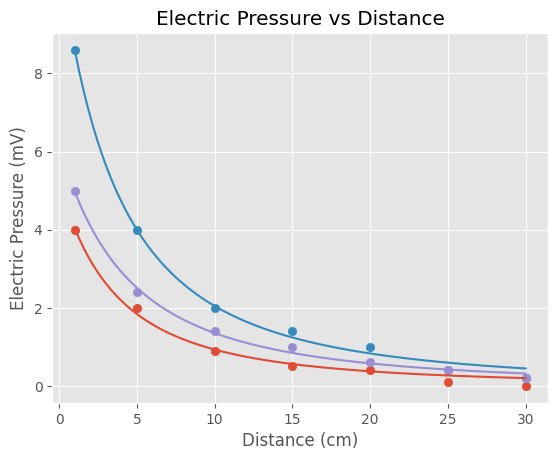

In [4]:
def model(x, d0, k):
    return k / (x + d0)**2

def fit_model(data, distance):
    popt, _ = curve_fit(model, distance, data)
    return popt

d1, k1 = fit_model(data1, distance)
d2, k2 = fit_model(data2, distance)
d3, k3 = fit_model(data3, distance)

regression2 = np.poly1d(np.polyfit(distance, data2, deg=2))

regression3 = np.poly1d(np.polyfit(distance, data3, deg=2))

distance_linspace = np.linspace(distance.min(), distance.max(), 100)

data1_smooth = model(distance_linspace, d1, k1)

data2_smooth = model(distance_linspace, d2, k2)

data3_smooth = model(distance_linspace, d3, k3)

plt.style.use('ggplot')

plt.xlabel("Distance (cm)")
plt.ylabel("Electric Pressure (mV)")
plt.title("Electric Pressure vs Distance")

plt.scatter(distance, data1, color="C0")
plt.scatter(distance, data2, color="C1")
plt.scatter(distance, data3, color="C2")

plt.plot(distance_linspace, data1_smooth, color="C0")
plt.plot(distance_linspace, data2_smooth, color="C1")
plt.plot(distance_linspace, data3_smooth, color="C2")

print(f"Data 1: k = {k1:.2f} mV*cm^2 and d0 = {d1:.2f} cm")
print(f"Data 2: k = {k2:.2f} mV*cm^2 and d0 = {d2:.2f} cm")
print(f"Data 3: k = {k3:.2f} mV*cm^2 and d0 = {d3:.2f} cm")